# SomnIA — Vision Transformer **ViT-B/16** sobre el DDD completo

Réplica del enfoque del paper de **Hassan et al. (2025)**, *"Real-time driver drowsiness detection using transformer architectures"*, con su **mejor modelo, el ViT** (99,15 % en MRL, Tabla 8), evaluado **por persona**.

Este notebook es **independiente**: todo el código está aquí. La CNN está en `SomnIA_CNN.ipynb`, con el mismo flujo; al final se comparan ambos.
Los pesos entrenados están guardados en `results/ddd_full/vitb16/` (5 pliegues). Con `RETRAIN = False` **no se entrena de nuevo**: se cargan los pesos y las predicciones guardadas.

### Flujo: qué se toma del paper y qué se ajusta

| Paso | Paper | Este notebook |
|---|---|---|
| 1. Datos | MRL (ojos) y NTHU-DDD | **DDD completo** (41.793 caras de conductores, Kaggle) |
| 2. Personas | No se identifican | Reconocimiento facial (FaceNet) para saber quién es cada persona |
| 3. División | Aleatoria 80/20 por imagen | **Por persona**, validación cruzada de 5 pliegues y validación separada para el early stopping |
| 4. Región de interés | Haar localiza cara y ojos | Recorte de **cada ojo** con los puntos faciales de MediaPipe, en gris como MRL |
| 5. Tarea del modelo | Ojo abierto / cerrado (etiqueta manual de MRL) | **Grado de cierre del ojo**, con `eyeBlink` de MediaPipe como etiqueta por imagen |
| 6. Modelo | ViT-B/16 preentrenado | El mismo, con los hiperparámetros base del paper |
| 7. Decisión | Umbral fijo y contador de 15 fotogramas | **Calibración por persona** y regresión logística **por fotograma** |
| 8. Validación extra | — | **Prueba de fuga** de la calibración |
| 9. Interpretabilidad | CAM (Fig. 26) | **Grad-CAM** y attention rollout |

Toda la evaluación es **por fotograma**. Se reportan los resultados en **entrenamiento** y en **prueba** (personas que el modelo nunca vio).

## Resumen de resultados

Evaluación **por fotograma**, calibrada por persona, con validación cruzada de **5 pliegues por persona**. En la prueba se usan solo **personas que el modelo nunca vio**.

| Modelo | Conjunto | Correlación cierre | Accuracy | Detecta Drowsy | Reconoce alerta | F1 |
|---|---|---|---|---|---|---|
| **VGG19 + Attention** | Entrenamiento | 0,980 | 74,4 ± 1,8 % | 66,6 % | 83,9 % | 73,9 % |
| | **Prueba** | **0,912** | 71,6 ± 5,2 % | 65,9 % | 78,6 % | 71,1 % |
| **ViT-B/16** | Entrenamiento | 0,976 | 73,9 ± 2,4 % | 64,4 % | 85,3 % | 72,9 % |
| | **Prueba** | 0,869 | **74,5 ± 4,6 %** | **69,3 %** | **80,6 %** | **74,0 %** |

Los detalles, gráficas y el análisis completo están en la sección 13.

## 0. Configuración y hardware

In [1]:
import copy, math, re, time, warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.cluster import AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
RAW = ROOT / "data/raw/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1/Driver Drowsiness Dataset (DDD)"
PREP = ROOT / "data/processed/ddd_full"            # caché del preprocesamiento (compartida con el otro notebook)
RESULTS = ROOT / "results/ddd_full"                # pesos, predicciones e historiales de entrenamiento
LANDMARK_MODEL = ROOT / "models/face_landmarker.task"
CLASSES = ["Non Drowsy", "Drowsy"]                 # 0 = alerta, 1 = somnoliento (clase positiva)
SEED, N_FOLDS, N_CALIB, EYE_SIZE = 42, 5, 20, 96
RETRAIN = False                                    # False = usa los pesos ya entrenados (no entrena)


def setup_device():
    # Detecta el hardware y activa sus optimizaciones
    if torch.cuda.is_available():                                   # NVIDIA
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        amp = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        return torch.device("cuda"), amp, torch.cuda.get_device_name(0)
    if torch.backends.mps.is_available():                           # GPU de Apple
        return torch.device("mps"), torch.float16, "Apple GPU (MPS)"
    return torch.device("cpu"), torch.bfloat16, "CPU"


def memory_format(dev):
    # channels_last acelera en NVIDIA, pero en la GPU de Apple hace más lentas a las CNN (hasta 4x)
    return torch.channels_last if dev.type == "cuda" else torch.contiguous_format


DEVICE, AMP_DTYPE, HW = setup_device()
print(f"Python {__import__('sys').version.split()[0]} | PyTorch {torch.__version__}")
print(f"Hardware: {HW} | dispositivo: {DEVICE} | precisión mixta: {AMP_DTYPE}")
if DEVICE.type == "cuda":
    print("Optimización NVIDIA activa: AMP + TF32 + cudnn.benchmark + channels_last + torch.compile")
elif DEVICE.type == "mps":
    print("GPU de Apple: AMP fp16 (CUDA no existe en macOS; en Kaggle o Colab la optimización NVIDIA se activa sola)")

Python 3.14.6 | PyTorch 2.14.0
Hardware: Apple GPU (MPS) | dispositivo: mps | precisión mixta: torch.float16
GPU de Apple: AMP fp16 (CUDA no existe en macOS; en Kaggle o Colab la optimización NVIDIA se activa sola)


## 1. Dataset: DDD completo

**Driver Drowsiness Dataset** ([Kaggle](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd)): caras de conductores recortadas de los videos del *Real-Life Drowsiness Dataset*, en color y de 227×227 px.
Cada video tiene una etiqueta, *Drowsy* o *Non Drowsy*, según cómo dijo sentirse la persona.
El nombre de cada archivo es un **prefijo de sujeto** más un número de fotograma: `A0001.png` es el fotograma 1 del sujeto A somnoliento, y `a0001.png` el del mismo sujeto alerta.

41,793 imágenes | prefijos: Drowsy 28, Non Drowsy 26


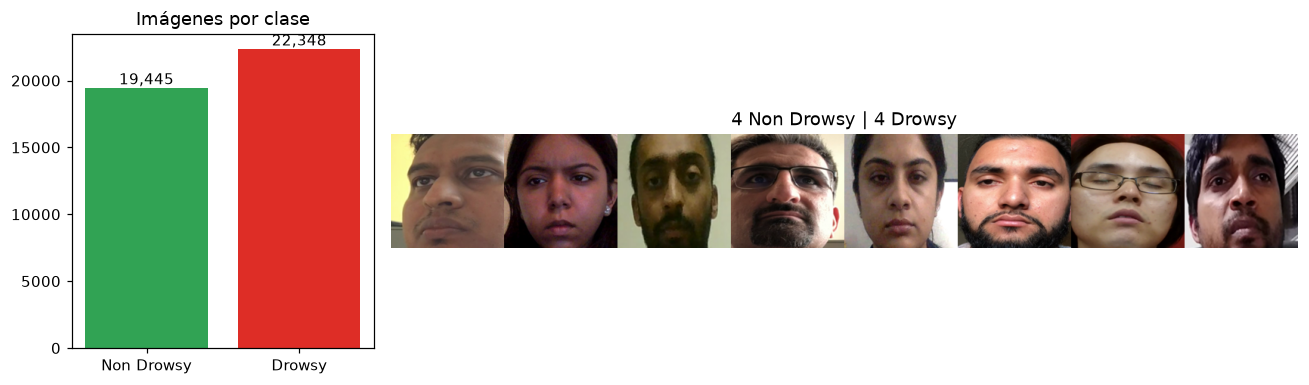

In [2]:
if not RAW.exists():   # descarga oficial de Kaggle (2,3 GB)
    import os, kagglehub
    os.environ["KAGGLEHUB_CACHE"] = str(ROOT / "data/raw/kagglehub")
    kagglehub.dataset_download("ismailnasri20/driver-drowsiness-dataset-ddd")

def scan():
    rows = []
    for label, cls in enumerate(CLASSES):
        for p in sorted((RAW / cls).glob("*.png")):
            m = re.match(r"^([A-Za-z]+)(\d+)\.png$", p.name)
            rows.append({"rel_path": f"{cls}/{p.name}", "label": label, "class_name": cls,
                         "prefix": m.group(1), "frame": int(m.group(2))})
    return pd.DataFrame(rows)

PREP.mkdir(parents=True, exist_ok=True)
if not (PREP / "index.csv").exists():
    scan().to_csv(PREP / "index.csv", index=False)
index = pd.read_csv(PREP / "index.csv")
print(f"{len(index):,} imágenes | prefijos: Drowsy {index.loc[index.label == 1, 'prefix'].nunique()}, Non Drowsy {index.loc[index.label == 0, 'prefix'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1, 3]})
counts = index["class_name"].value_counts().reindex(CLASSES)
axes[0].bar(counts.index, counts.values, color=["#31a354", "#de2d26"]); axes[0].set_title("Imágenes por clase")
for i, v in enumerate(counts.values): axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")
sample = index.groupby("label").sample(4, random_state=1)
strip = np.concatenate([np.asarray(Image.open(RAW / r).convert("RGB").resize((150, 150))) for r in sample["rel_path"]], axis=1)
axes[1].imshow(strip); axes[1].axis("off"); axes[1].set_title("4 Non Drowsy | 4 Drowsy")
plt.tight_layout(); plt.show()

## 2. Identificar a la persona de cada foto

**Paper:** no identifica personas; trata cada imagen como independiente.
**Aquí:** para dividir por persona hay que saber quién es cada una. **FaceNet**, un modelo de reconocimiento facial entrenado en VGGFace2, convierte cada cara en un vector de 512 números: dos fotos de la misma persona dan vectores muy parecidos.
Los vectores se agrupan con **clustering jerárquico** (distancia coseno):
- **Umbral 0,5 para dividir.** Es conservador: nunca parte a una persona en dos grupos, lo que la pondría en entrenamiento y prueba a la vez.
- **Umbral 0,4 para calibrar.** Es fino: cada persona se compara solo con sus propias fotos.

Como el clustering de 41.800 fotos necesitaría una matriz de 41.800 × 41.800, se agrupa una muestra de 9.000 y el resto se asigna al grupo más parecido.

In [3]:
@torch.no_grad()
def facenet_embeddings(paths, batch=256):
    from facenet_pytorch import InceptionResnetV1
    net = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)
    out = []
    for i in range(0, len(paths), batch):
        x = np.stack([(np.asarray(Image.open(p).convert("RGB").resize((160, 160)), dtype=np.float32) - 127.5) / 128
                      for p in paths[i:i + batch]])
        out.append(F.normalize(net(torch.from_numpy(x).permute(0, 3, 1, 2).to(DEVICE)), dim=1).cpu().numpy())
    return np.concatenate(out)

def cluster_persons(emb, threshold, sample=9000):
    idx = np.random.default_rng(0).choice(len(emb), min(sample, len(emb)), replace=False)
    lab = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold, metric="cosine",
                                  linkage="average").fit_predict(emb[idx])
    cents = np.stack([emb[idx][lab == c].mean(0) for c in range(lab.max() + 1)])
    sims = emb @ (cents / np.linalg.norm(cents, axis=1, keepdims=True)).T
    return sims.argmax(1), sims.max(1)

if not (PREP / "facenet.npy").exists():   # ~2 min en GPU
    np.save(PREP / "facenet.npy", facenet_embeddings([str(RAW / r) for r in index["rel_path"]]))
EMB = np.load(PREP / "facenet.npy")
if not (PREP / "persons.csv").exists():
    (coarse, sim), (fine, _) = cluster_persons(EMB, 0.5), cluster_persons(EMB, 0.4)
    order = {c: k for k, c in enumerate(pd.Series(coarse).value_counts().index)}
    pd.DataFrame({"rel_path": index["rel_path"], "person": [f"P{order[c]:02d}" for c in coarse],
                  "identity": [f"P{order[c]:02d}-{f}" for c, f in zip(coarse, fine)],
                  "person_sim": sim}).to_csv(PREP / "persons.csv", index=False)
persons = pd.read_csv(PREP / "persons.csv")
data = index.merge(persons, on="rel_path")

print(f"Personas (umbral 0,5): {data['person'].nunique()} | identidades para calibrar (0,4): {data['identity'].nunique()}")
purity = data.groupby(["class_name", "prefix"])["person"].agg(lambda s: s.value_counts(normalize=True).iloc[0])
print(f"Prefijos cuya persona principal cubre < 95 % de sus fotos: {(purity < 0.95).sum()} de {len(purity)}")
same = data.assign(p=data["prefix"].str.lower()).groupby("p")["person"].nunique().eq(1).mean()
print(f"Prefijos en que la versión Drowsy (A) y Non Drowsy (a) son la misma persona: {same:.0%}")
table = pd.crosstab(data["person"], data["class_name"]).reindex(columns=CLASSES)
table.T

Personas (umbral 0,5): 26 | identidades para calibrar (0,4): 30
Prefijos cuya persona principal cubre < 95 % de sus fotos: 0 de 54
Prefijos en que la versión Drowsy (A) y Non Drowsy (a) son la misma persona: 96%


person,P00,P01,P02,P03,P04,P05,P06,P07,P08,P09,...,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25
class_name,,,,,,,,,,,,,,,,,,,,,
Non Drowsy,1143,1237,1252,1288,1500,1526,1045,957,1000,671,...,190,522,381,571,457,0,510,399,409,109
Drowsy,1749,1551,1411,1346,1112,741,1095,1156,962,1097,...,963,619,732,508,487,933,420,335,315,499


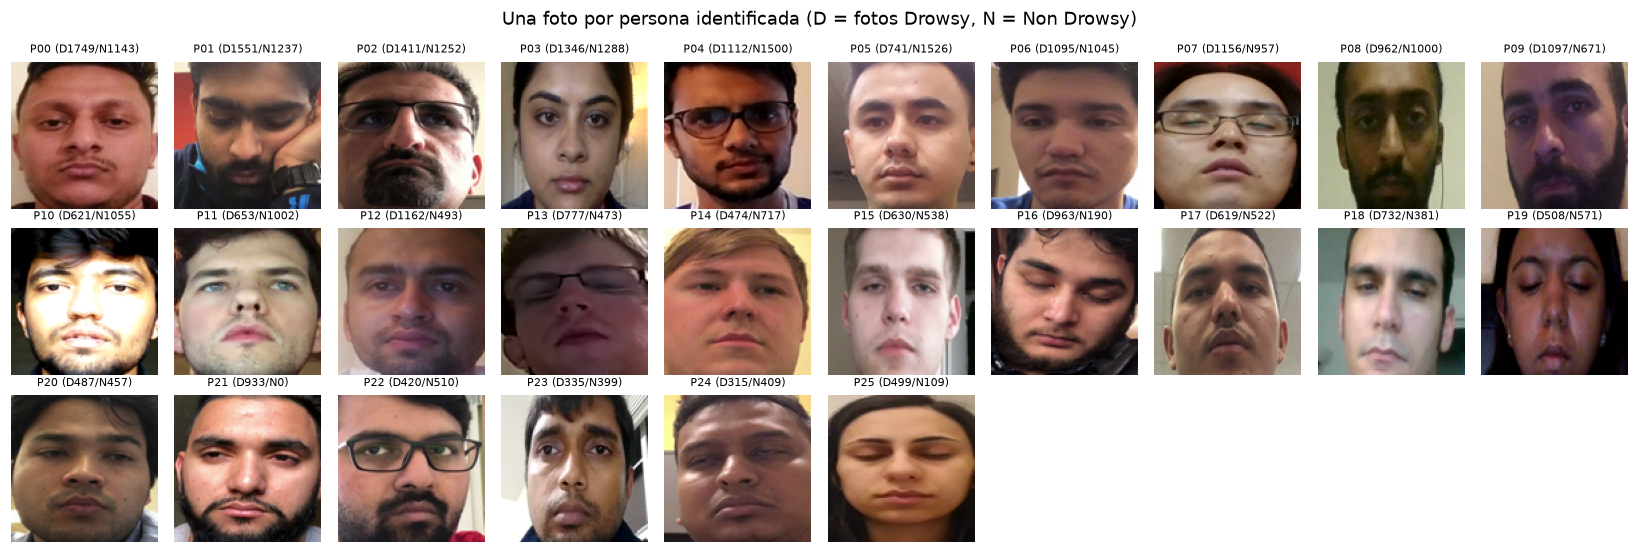

In [4]:
people = table.index.tolist()
rows_ = int(np.ceil(len(people) / 10))
fig, axes = plt.subplots(rows_, 10, figsize=(15, 1.7 * rows_))
for ax in axes.ravel(): ax.axis("off")
for ax, p in zip(axes.ravel(), people):
    r = data[data["person"] == p].sample(1, random_state=0).iloc[0]
    ax.imshow(Image.open(RAW / r["rel_path"]).convert("RGB").resize((110, 110)))
    ax.set_title(f"{p} (D{table.loc[p, 'Drowsy']}/N{table.loc[p, 'Non Drowsy']})", fontsize=7)
plt.suptitle("Una foto por persona identificada (D = fotos Drowsy, N = Non Drowsy)"); plt.tight_layout(); plt.show()

## 3. Por qué no se usa la división del paper

**Paper:** divide al azar 80/20 por imagen y reporta ~99 %.
**Aquí:** con esa misma división se busca, para cada foto de prueba, la foto de entrenamiento con la cara más parecida.

In [5]:
tr_idx, te_idx = train_test_split(np.arange(len(EMB)), test_size=0.2, stratify=data["label"], random_state=SEED)
E_tr = torch.from_numpy(EMB[tr_idx]).to(DEVICE)
twin = np.concatenate([(torch.from_numpy(EMB[te_idx[i:i + 2048]]).to(DEVICE) @ E_tr.T).max(1).values.cpu().numpy()
                       for i in range(0, len(te_idx), 2048)])
del E_tr
print(f"Fotos de prueba con una foto de la misma persona en entrenamiento (similitud > 0,8): {(twin > 0.8).mean():.1%}")
print(f"Similitud mediana con su 'gemela' de entrenamiento: {np.median(twin):.3f}")

Fotos de prueba con una foto de la misma persona en entrenamiento (similitud > 0,8): 100.0%
Similitud mediana con su 'gemela' de entrenamiento: 0.994


Casi todas las fotos de prueba tienen una **gemela** de la misma persona en entrenamiento: de ahí sale el ~99 % del paper. Por eso aquí se divide **por persona**.

## 4. Región de interés y etiqueta del ojo

**Paper:** cascadas de Haar localizan la cara y los ojos, y el modelo clasifica imágenes de **un solo ojo en gris** (MRL), etiquetadas a mano como abierto o cerrado.
**Aquí:**
- **Recorte:** MediaPipe Face Landmarker localiza 478 puntos de la cara. Los 16 del contorno de cada ojo dan un cuadrado centrado en el ojo, de 1,6 veces su ancho, en gris y a 96×96.
- **Etiqueta:** el DDD no tiene etiqueta por ojo. MediaPipe estima `eyeBlink`, entre 0 (abierto) y 1 (cerrado), y se usa como **etiqueta de cada imagen**. Así el modelo no puede acertar reconociendo a la persona.

La extracción recorre las 41.800 fotos una sola vez (~15 min en un núcleo) y queda guardada.

Fotos con ambos ojos recortados: 41,769 de 41,793 | usadas (personas con ambas clases): 40,836


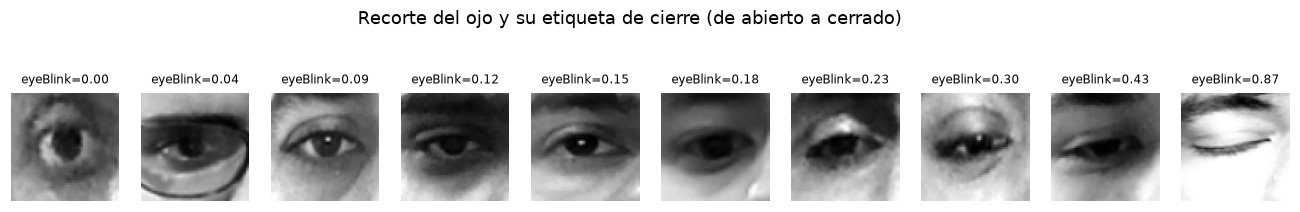

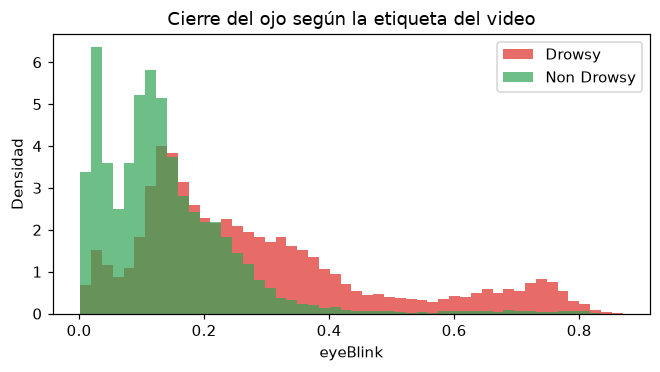

In [6]:
LEFT_CONTOUR = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_CONTOUR = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]

def crop_eyes(bgr, pts):
    gray = cv2.copyMakeBorder(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), 64, 64, 64, 64, cv2.BORDER_REPLICATE)
    crops = []
    for ids in (LEFT_CONTOUR, RIGHT_CONTOUR):
        e = pts[ids]
        (cx, cy), half = e.mean(0), max(np.ptp(e[:, 0]), 1) * 0.8          # cuadrado de 1,6 veces el ancho del ojo
        x0, y0, x1, y1 = (int(round(v)) + 64 for v in (cx - half, cy - half, cx + half, cy + half))
        crops.append(cv2.resize(gray[y0:y1, x0:x1], (EYE_SIZE, EYE_SIZE), interpolation=cv2.INTER_AREA))
    return np.stack(crops)

def extract_eyes():
    import mediapipe as mp
    from mediapipe.tasks.python import BaseOptions, vision
    lm = vision.FaceLandmarker.create_from_options(vision.FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(LANDMARK_MODEL), delegate=BaseOptions.Delegate.CPU),
        num_faces=1, output_face_blendshapes=True))
    crops = np.zeros((len(index), 2, EYE_SIZE, EYE_SIZE), np.uint8)
    found, bl, br = np.zeros(len(index), bool), np.full(len(index), np.nan), np.full(len(index), np.nan)
    for i, rel in enumerate(index["rel_path"]):
        bgr = cv2.imread(str(RAW / rel))
        res = lm.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)))
        if not res.face_landmarks:
            continue
        h, w = bgr.shape[:2]
        pts = np.array([[q.x * w, q.y * h] for q in res.face_landmarks[0]])
        bs = {b.category_name: b.score for b in res.face_blendshapes[0]}
        crops[i], found[i], bl[i], br[i] = crop_eyes(bgr, pts), True, bs["eyeBlinkLeft"], bs["eyeBlinkRight"]
    np.save(PREP / "eyes.npy", crops)
    pd.DataFrame({"rel_path": index["rel_path"], "found": found, "blink_L": bl, "blink_R": br}).to_csv(PREP / "eyes.csv", index=False)

if not (PREP / "eyes.npy").exists():
    extract_eyes()
EYES = np.load(PREP / "eyes.npy", mmap_mode="r")
data = data.merge(pd.read_csv(PREP / "eyes.csv"), on="rel_path")
ok = data["found"].astype(bool)
both = data[ok].groupby("person")["label"].nunique().eq(2)
use = ok & data["person"].isin(both[both].index)
print(f"Fotos con ambos ojos recortados: {ok.sum():,} de {len(data):,} | usadas (personas con ambas clases): {use.sum():,}")

ranked = data[ok].sort_values("blink_L")
picks = ranked.iloc[np.linspace(0, len(ranked) - 1, 10).astype(int)]
fig, axes = plt.subplots(1, 10, figsize=(15, 2.2))
for ax, (i, r) in zip(axes, picks.iterrows()):
    ax.imshow(EYES[i, 0], cmap="gray"); ax.axis("off"); ax.set_title(f"eyeBlink={r['blink_L']:.2f}", fontsize=8)
plt.suptitle("Recorte del ojo y su etiqueta de cierre (de abierto a cerrado)", y=1.06); plt.show()

fig, ax = plt.subplots(figsize=(7, 3.3))
ax.hist([data.loc[ok & (data["label"] == l), "blink_L"] for l in (0, 1)], bins=50, density=True,
        color=["#31a354", "#de2d26"], alpha=0.7, histtype="stepfilled", label=CLASSES)
ax.set(title="Cierre del ojo según la etiqueta del video", xlabel="eyeBlink", ylabel="Densidad"); ax.legend(); plt.show()

## 5. Validación cruzada por persona

**Paper:** un solo corte aleatorio, y el conjunto de prueba se usa también para elegir la mejor época.
**Aquí:** se usan las personas con fotos de **ambas clases**, porque la calibración necesita fotos de la persona alerta. En cada uno de los 5 pliegues:
- Un grupo de personas es la **prueba**: nunca se usa para entrenar.
- De las demás, una parte es **validación**, para el early stopping, y el resto es **entrenamiento**.

Los fotogramas consecutivos de un video son casi iguales, así que se entrena con 1 de cada 3 y se valida con 1 de cada 4. La prueba usa **todos** los fotogramas.

In [7]:
D = data[use].copy()
D["row"] = D.index               # posición en EYES
D = D.reset_index(drop=True)
FOLDS = []
for k, (trval, te) in enumerate(StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=SEED).split(D, D["label"], D["person"])):
    rest = D.iloc[trval]
    _, va = next(StratifiedGroupKFold(4, shuffle=True, random_state=SEED).split(rest, rest["label"], rest["person"]))
    va_idx = rest.index[va]; tr_idx = rest.index.difference(va_idx)
    sub = lambda idx, step: D.loc[idx].sort_values(["prefix", "frame"]).index[::step].to_numpy()
    FOLDS.append({"train": sub(tr_idx, 3), "val": sub(va_idx, 4), "test": D.index[te].to_numpy()})
pd.DataFrame([{"Pliegue": k,
               "Personas entrenamiento": D.loc[f["train"], "person"].nunique(),
               "Personas validación": ", ".join(sorted(D.loc[f["val"], "person"].unique())),
               "Personas prueba": ", ".join(sorted(D.loc[f["test"], "person"].unique())),
               "Fotos entrenamiento": len(f["train"]), "Fotos prueba": len(f["test"])} for k, f in enumerate(FOLDS)])

,Pliegue,Personas entrenamiento,Personas validación,Personas prueba,Fotos entrenamiento,Fotos prueba
0,0,15,"P01, P03, P09, P16, P23","P05, P07, P15, P18, P20",8052,7604
1,1,14,"P05, P06, P14, P18, P22, P24","P01, P03, P09, P16, P23",7802,9077
2,2,15,"P01, P03, P09, P16, P23","P00, P13, P14, P19, P24",8209,7132
3,3,15,"P05, P07, P15, P18, P20","P04, P06, P12, P17, P22",8255,8469
4,4,15,"P05, P06, P07, P18, P19","P02, P08, P10, P11, P25",7857,8554


## 6. Modelo: Vision Transformer (ViT-B/16)

**Paper:** `google/vit-base-patch16-224` preentrenado. La imagen se corta en 196 parches de 16×16; 12 bloques de *self-attention* relacionan cada parche con los demás, y el token `[CLS]` resume la imagen. Hiperparámetros (Tabla 6): **AdamW**, learning rate **5e-5**.
**Aquí:** el mismo checkpoint y los mismos hiperparámetros base. La salida es **una neurona** con el cierre del ojo (0–1).
Como el DDD tiene muchas menos personas que MRL, se congelan los primeros 8 de 12 bloques y se usa weight decay de 0,05, para que no memorice identidades. Lotes de 64 (el paper usa 32), por la precisión mixta.

In [8]:
from transformers import ViTForImageClassification
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

def build_model(attn="sdpa", frozen_blocks=8):
    m = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", num_labels=1,
                                                  ignore_mismatched_sizes=True, attn_implementation=attn)
    m.vit.embeddings.requires_grad_(False)
    blocks = m.vit.layers if hasattr(m.vit, "layers") else m.vit.encoder.layer
    for layer in blocks[:frozen_blocks]:
        layer.requires_grad_(False)
    m.is_hf, m.mean, m.std = True, (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
    return m

HP = {"optimizer": "AdamW", "lr": 5e-5, "weight_decay": 0.05, "batch_size": 64, "eval_batch_size": 256,
      "image_size": 224, "max_epochs": 6, "patience": 2, "seed": SEED}
m = build_model()
pd.DataFrame([{"Modelo": "ViT-B/16", "Parámetros": f"{sum(p.numel() for p in m.parameters()):,}",
               "Entrenables": f"{sum(p.numel() for p in m.parameters() if p.requires_grad):,}", **HP}])

,Modelo,Parámetros,Entrenables,optimizer,lr,weight_decay,batch_size,eval_batch_size,image_size,max_epochs,patience,seed
0,ViT-B/16,"85,799,425","28,353,793",AdamW,0.00005,0.05,64,256,224,6,2,42


## 7. Entrenamiento por pliegue

**Paper:** entrena una vez, hasta 30 épocas, con paciencia 5 sobre el conjunto de prueba.
**Aquí**, para cada pliegue:
1. Se entrena solo con las personas de entrenamiento. Pérdida BCE contra `eyeBlink`; early stopping con **validación** (paciencia 2, máximo 6 épocas).
2. Se predice el cierre de ambos ojos en entrenamiento y en prueba.

**Optimización de velocidad:**
- Los recortes se cargan **una vez en la memoria de la GPU**.
- Cada lote se arma, se aumenta (rotación, escala, desplazamiento, brillo y contraste, distintos para cada imagen) y se redimensiona a 224×224 **en la GPU**, con **precisión mixta**.
- Con NVIDIA se activan además TF32, `channels_last` y `torch.compile`.

**Pesos guardados:** `results/ddd_full/<modelo>/model_fold{k}.pt`, junto con `fold{k}.csv` (predicciones) y `history_fold{k}.csv` (pérdidas por época). Con `RETRAIN = False` se cargan y **no se entrena**.

In [9]:
def make_batch(eyes_dev, frames, sides, train, size, mean, std):
    # Lote en la GPU: recorte -> aumento de datos (solo en train) -> 224x224 -> 3 canales -> normalización
    x = eyes_dev[frames, sides].float().div_(255).unsqueeze(1)
    b = x.shape[0]
    if train:
        ang = (torch.rand(b, device=x.device) * 2 - 1) * math.radians(10)             # rotación ±10°
        sc = 1 / (0.9 + torch.rand(b, device=x.device) * 0.2)                          # escala 0,9-1,1
        tx, ty = [(torch.rand(b, device=x.device) * 2 - 1) * 0.08 for _ in range(2)]   # desplazamiento ±8 %
        theta = torch.stack([torch.stack([sc * torch.cos(ang), -sc * torch.sin(ang), tx], 1),
                             torch.stack([sc * torch.sin(ang), sc * torch.cos(ang), ty], 1)], 1)
        x = F.grid_sample(x, F.affine_grid(theta, x.shape, align_corners=False), padding_mode="border", align_corners=False)
        mu = x.mean(dim=(2, 3), keepdim=True)
        x = (x - mu) * (0.7 + torch.rand(b, 1, 1, 1, device=x.device) * 0.6) + mu      # contraste ±30 %
        x = (x * (0.7 + torch.rand(b, 1, 1, 1, device=x.device) * 0.6)).clamp_(0, 1)   # brillo ±30 %
    x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False).expand(-1, 3, -1, -1)
    mean = torch.tensor(mean, device=x.device).view(1, 3, 1, 1); std = torch.tensor(std, device=x.device).view(1, 3, 1, 1)
    return ((x - mean) / std).contiguous(memory_format=memory_format(x.device))

def forward_logit(model, x):
    out = model(pixel_values=x) if getattr(model, "is_hf", False) else model(x)
    return (out.logits if hasattr(out, "logits") else out).reshape(-1).float()

@torch.no_grad()
def predict_closure(model, eyes_dev, frames, sides, run=None):
    run = run or model; model.eval(); out = []
    for i in range(0, len(frames), HP["eval_batch_size"]):
        x = make_batch(eyes_dev, frames[i:i + HP["eval_batch_size"]], sides[i:i + HP["eval_batch_size"]], False,
                       HP["image_size"], model.mean, model.std)
        with torch.autocast(DEVICE.type, dtype=AMP_DTYPE):
            out.append(torch.sigmoid(forward_logit(run, x)).cpu())
    return torch.cat(out).numpy()

def both_eyes(frames):   # cada fotograma aporta 2 muestras: ojo izquierdo y ojo derecho
    return torch.as_tensor(np.repeat(frames, 2), device=DEVICE), torch.tensor([0, 1] * len(frames), device=DEVICE)

def train_fold(eyes_dev, target, tr_frames, va_frames):
    torch.manual_seed(SEED)
    model = build_model().to(DEVICE).to(memory_format=memory_format(DEVICE))
    run = torch.compile(model) if DEVICE.type == "cuda" else model
    params = [p for p in model.parameters() if p.requires_grad]
    opt = (torch.optim.AdamW if HP["optimizer"] == "AdamW" else torch.optim.Adam)(params, lr=HP["lr"], weight_decay=HP["weight_decay"])
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda" and AMP_DTYPE == torch.float16))
    (tr_f, tr_s), (va_f, va_s) = both_eyes(tr_frames), both_eyes(va_frames)
    best, best_state, wait, history = float("inf"), None, 0, []
    for epoch in range(1, HP["max_epochs"] + 1):
        t0 = time.time(); model.train(); perm = torch.randperm(len(tr_f), device=DEVICE); total = 0.0
        for i in range(0, len(perm), HP["batch_size"]):
            j = perm[i:i + HP["batch_size"]]
            x = make_batch(eyes_dev, tr_f[j], tr_s[j], True, HP["image_size"], model.mean, model.std)
            with torch.autocast(DEVICE.type, dtype=AMP_DTYPE):
                logit = forward_logit(run, x)
            loss = F.binary_cross_entropy_with_logits(logit, target[tr_f[j], tr_s[j]])
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            total += loss.item() * len(j)
        pred = predict_closure(model, eyes_dev, va_f, va_s, run); tgt = target[va_f, va_s].cpu().numpy()
        val_loss = F.binary_cross_entropy(torch.tensor(pred).clamp(1e-6, 1 - 1e-6), torch.tensor(tgt)).item()
        history.append({"epoch": epoch, "train_loss": total / len(perm), "val_loss": val_loss,
                        "val_corr": float(np.corrcoef(pred, tgt)[0, 1]), "seconds": round(time.time() - t0, 1)})
        print(f"  época {epoch}: train {history[-1]['train_loss']:.4f} | val {val_loss:.4f} | corr val {history[-1]['val_corr']:.3f}")
        if val_loss < best:
            best, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= HP["patience"]:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [10]:
OUT = RESULTS / "vitb16"; OUT.mkdir(parents=True, exist_ok=True)
eyes_dev = torch.from_numpy(np.ascontiguousarray(EYES[D["row"].to_numpy()])).to(DEVICE)   # recortes en la GPU
target = torch.tensor(D[["blink_L", "blink_R"]].to_numpy(np.float32), device=DEVICE)
print(f"Recortes en la GPU: {tuple(eyes_dev.shape)} ({eyes_dev.numel() / 2**20:.0f} MB)")

PRED, HIST = {}, {}
for k, f in enumerate(FOLDS):
    files = [OUT / f"fold{k}.csv", OUT / f"history_fold{k}.csv", OUT / f"model_fold{k}.pt"]
    if all(p.exists() for p in files) and not RETRAIN:
        PRED[k], HIST[k] = pd.read_csv(files[0]), pd.read_csv(files[1])
        print(f"Pliegue {k}: pesos y predicciones cargados de {OUT.relative_to(ROOT)} (sin reentrenar)")
        continue
    print(f"Pliegue {k}: entrenando…"); t0 = time.time()
    model, hist = train_fold(eyes_dev, target, f["train"], f["val"])
    frames = np.concatenate([f["train"], f["test"]])
    closure = predict_closure(model, eyes_dev, *both_eyes(frames)).reshape(-1, 2)
    PRED[k] = D.loc[frames, ["rel_path", "label", "person", "identity", "prefix", "frame", "blink_L", "blink_R"]].assign(
        closure_L=closure[:, 0], closure_R=closure[:, 1], split=["train"] * len(f["train"]) + ["test"] * len(f["test"]))
    HIST[k] = hist
    PRED[k].to_csv(files[0], index=False); hist.to_csv(files[1], index=False); torch.save(model.state_dict(), files[2])
    print(f"  listo en {(time.time() - t0) / 60:.1f} min"); del model

Recortes en la GPU: (40836, 2, 96, 96) (718 MB)
Pliegue 0: pesos y predicciones cargados de results/ddd_full/vitb16 (sin reentrenar)
Pliegue 1: pesos y predicciones cargados de results/ddd_full/vitb16 (sin reentrenar)
Pliegue 2: pesos y predicciones cargados de results/ddd_full/vitb16 (sin reentrenar)
Pliegue 3: pesos y predicciones cargados de results/ddd_full/vitb16 (sin reentrenar)
Pliegue 4: pesos y predicciones cargados de results/ddd_full/vitb16 (sin reentrenar)


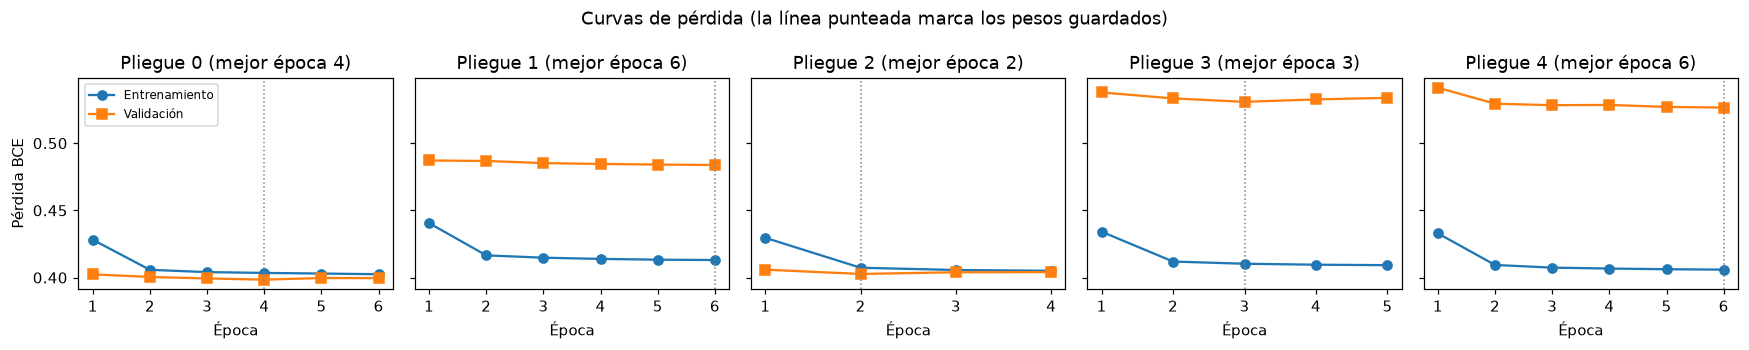

,Pliegue 0,Pliegue 1,Pliegue 2,Pliegue 3,Pliegue 4
Épocas,6.0,6.0,4.0,5.0,6.0
Mejor época,4.0,6.0,2.0,3.0,6.0
Seg./época,163.4,163.3,172.3,144.1,142.2


In [11]:
# Curvas de entrenamiento: pérdida en entrenamiento y en validación por época (cada pliegue)
fig, axes = plt.subplots(1, N_FOLDS, figsize=(16, 3.2), sharey=True)
for k, ax in enumerate(axes):
    h = HIST[k]
    ax.plot(h["epoch"], h["train_loss"], "o-", label="Entrenamiento")
    ax.plot(h["epoch"], h["val_loss"], "s-", label="Validación")
    best = h.loc[h["val_loss"].idxmin(), "epoch"]
    ax.axvline(best, color="gray", ls=":", lw=1)
    ax.set(title=f"Pliegue {k} (mejor época {best})", xlabel="Época")
axes[0].set_ylabel("Pérdida BCE"); axes[0].legend(fontsize=8)
plt.suptitle("Curvas de pérdida (la línea punteada marca los pesos guardados)"); plt.tight_layout(); plt.show()
pd.DataFrame({f"Pliegue {k}": {"Épocas": len(h), "Mejor época": int(h.loc[h['val_loss'].idxmin(), 'epoch']),
                                "Seg./época": round(h['seconds'].mean(), 1)} for k, h in HIST.items()})

## 8. ¿El modelo aprendió a medir el cierre del ojo?

Correlación entre el cierre que estima el modelo y el `eyeBlink` de MediaPipe, en **entrenamiento** y en **prueba**. 0 significa que no acierta nada y 1 que acierta perfecto.
Si la prueba se acerca al entrenamiento, el modelo **generaliza** a personas nuevas en lugar de memorizarlas.

,Entrenamiento,Prueba
Pliegue 0,0.976,0.851
Pliegue 1,0.979,0.895
Pliegue 2,0.959,0.877
Pliegue 3,0.980,0.886
Pliegue 4,0.985,0.836
Media,0.976,0.869


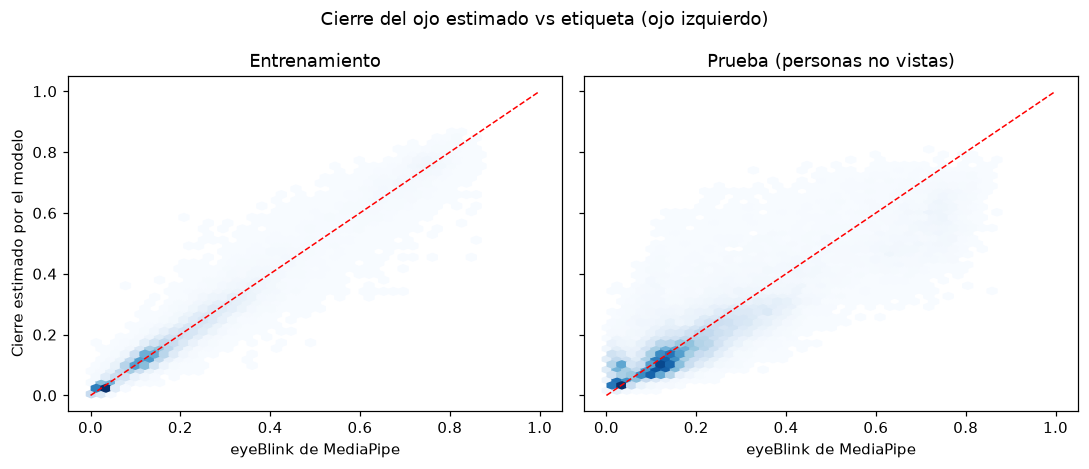

In [12]:
def corr(p):
    return np.corrcoef(p[["closure_L", "closure_R"]].to_numpy().ravel(), p[["blink_L", "blink_R"]].to_numpy().ravel())[0, 1]

corr_table = pd.DataFrame({f"Pliegue {k}": {"Entrenamiento": corr(p[p["split"] == "train"]), "Prueba": corr(p[p["split"] == "test"])}
                           for k, p in PRED.items()}).T
corr_table.loc["Media"] = corr_table.mean()
display(corr_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharey=True)
for ax, split, title in zip(axes, ["train", "test"], ["Entrenamiento", "Prueba (personas no vistas)"]):
    t = pd.concat([p[p["split"] == split] for p in PRED.values()])
    ax.hexbin(t["blink_L"], t["closure_L"], gridsize=40, cmap="Blues", mincnt=1); ax.plot([0, 1], [0, 1], "r--", lw=1)
    ax.set(title=title, xlabel="eyeBlink de MediaPipe")
axes[0].set_ylabel("Cierre estimado por el modelo")
plt.suptitle("Cierre del ojo estimado vs etiqueta (ojo izquierdo)"); plt.tight_layout(); plt.show()

## 9. Calibración por persona y clasificación por fotograma

**Paper:** un ojo con EAR < 0,25 está cerrado, con el mismo umbral para todos. Un contador de 15 fotogramas decide la somnolencia.
**Aquí:** un umbral fijo confunde ojos naturalmente pequeños con somnolencia. Al empezar a manejar, el sistema toma **20 fotos del conductor alerta** y expresa el cierre de cada ojo como desviación respecto a ese estado normal:
$z = (\text{cierre} - \mu_{\text{alerta}}) / \sigma_{\text{alerta}}$.
Se calibra **solo el número**, no la imagen. Después, una regresión logística (con pesos balanceados por clase), entrenada con las personas de entrenamiento, decide **cada fotograma** por separado.

In [13]:
FEATURES = {"sin calibrar": ["closure_L", "closure_R"],
            "calibrado por persona": ["z_L", "z_R", "closure_L", "closure_R"]}

def calibrate(frame, ref_label=0, n=N_CALIB):
    out = frame.copy(); out["is_calib"] = False
    for _, g in frame.groupby("identity"):
        ref = g[g["label"] == ref_label].sort_values(["prefix", "frame"]).index[:n]   # primeras fotos de referencia
        if len(ref) == 0:
            same = frame[(frame["person"] == g["person"].iloc[0]) & (frame["label"] == ref_label)]
            ref = same.sort_values(["prefix", "frame"]).index[:n]
        if len(ref) == 0:
            continue
        out.loc[ref, "is_calib"] = True
        for s in "LR":
            c = f"closure_{s}"
            out.loc[g.index, f"z_{s}"] = (frame.loc[g.index, c] - frame.loc[ref, c].mean()) / (frame.loc[ref, c].std() + 1e-3)
    return out

def metrics(y, pred):
    return {"accuracy": accuracy_score(y, pred), "precision": precision_score(y, pred, zero_division=0),
            "recall_drowsy": recall_score(y, pred), "recall_alerta": recall_score(y, pred, pos_label=0), "f1": f1_score(y, pred)}

def classify(ref_label_test=0):
    rows, preds = [], []
    for k, c in PRED.items():
        cal, test_cal = calibrate(c), calibrate(c, ref_label_test)
        train = cal[(cal["split"] == "train") & ~cal["is_calib"]].dropna(subset=FEATURES["calibrado por persona"])
        test = test_cal[(test_cal["split"] == "test") & ~cal["is_calib"] & ~test_cal["is_calib"]].dropna(subset=FEATURES["calibrado por persona"])
        for name, cols in FEATURES.items():
            clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")).fit(train[cols], train["label"])
            for conjunto, part in [("Entrenamiento", train), ("Prueba", test)]:
                prob = clf.predict_proba(part[cols])[:, 1]; pred = (prob >= 0.5).astype(int)
                rows.append({"variante": name, "conjunto": conjunto, "fold": k, **metrics(part["label"], pred)})
                if conjunto == "Prueba":
                    preds.append(part.assign(prob=prob, pred=pred, variante=name, fold=k))
    return pd.DataFrame(rows), pd.concat(preds)

def summarize(res):
    g = res.groupby(["variante", "conjunto"], sort=False)
    return pd.DataFrame({f"{m} (%)": g[m].mean().mul(100).round(1).astype(str) + " ± " + g[m].std().mul(100).round(1).astype(str)
                         for m in ["accuracy", "precision", "recall_drowsy", "recall_alerta", "f1"]})

RES, PREDS = classify()
results = summarize(RES)
results.to_csv(RESULTS / f"resultados_{'cnn' if 'VGG' in 'ViT-B/16' else 'vit'}.csv")
results

accuracy (%) precision (%)  \
variante              conjunto                                   
sin calibrar          Entrenamiento   69.4 ± 0.6    78.6 ± 3.0   
                      Prueba          66.8 ± 3.3   73.8 ± 11.1   
calibrado por persona Entrenamiento   73.9 ± 2.4    84.0 ± 2.3   
                      Prueba          74.5 ± 4.6    81.3 ± 9.9   

                                    recall_drowsy (%) recall_alerta (%)  \
variante              conjunto                                            
sin calibrar          Entrenamiento        60.6 ± 1.5        80.2 ± 2.1   
                      Prueba              63.9 ± 16.1       70.4 ± 22.4   
calibrado por persona Entrenamiento        64.4 ± 3.1        85.3 ± 1.9   
                      Prueba               69.3 ± 9.8       80.6 ± 14.4   

                                         f1 (%)  
variante              conjunto                   
sin calibrar          Entrenamiento  68.4 ± 1.1  
                      Prueba         66.4 ± 5.5  
calibrado por persona Entrenamiento  72.9 ± 2.5  
                      Prueba         74.0 ± 5.6

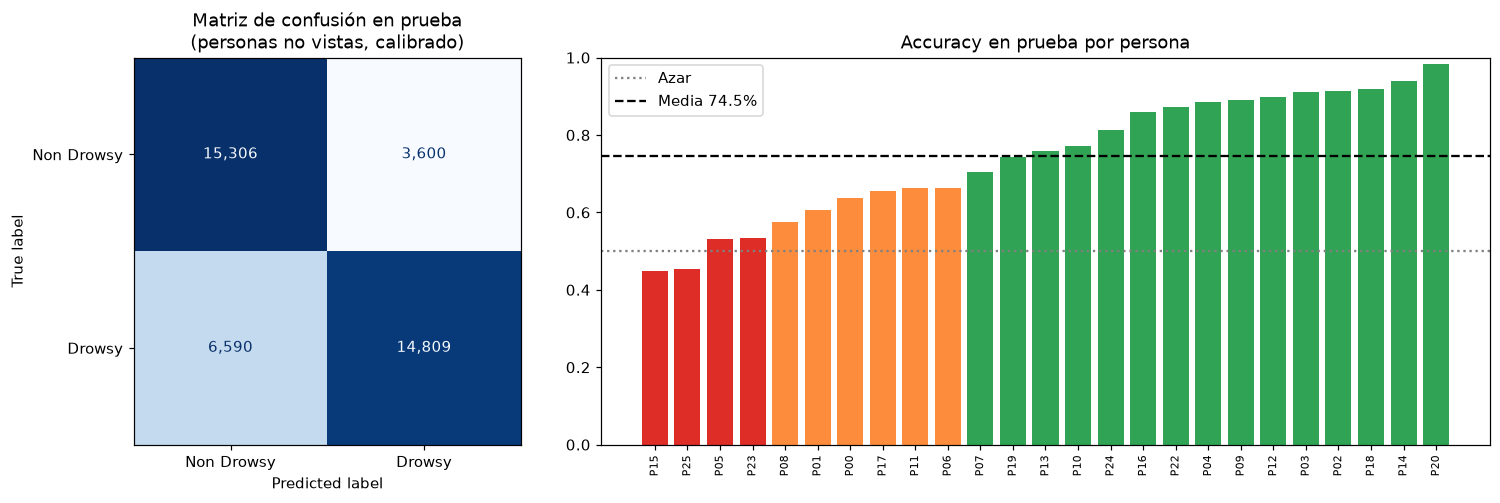

In [14]:
ev = PREDS.query("variante == 'calibrado por persona'")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 2]})
ConfusionMatrixDisplay(confusion_matrix(ev["label"], ev["pred"]), display_labels=CLASSES).plot(
    ax=axes[0], cmap="Blues", values_format=",d", colorbar=False)
axes[0].set_title("Matriz de confusión en prueba\n(personas no vistas, calibrado)")
acc_p = ev.groupby("person").apply(lambda g: (g["pred"] == g["label"]).mean()).sort_values()
axes[1].bar(acc_p.index, acc_p.values, color=["#de2d26" if v < 0.55 else "#fd8d3c" if v < 0.7 else "#31a354" for v in acc_p.values])
axes[1].axhline(0.5, color="gray", ls=":", label="Azar"); axes[1].axhline(acc_p.mean(), color="black", ls="--", label=f"Media {acc_p.mean():.1%}")
axes[1].set(title="Accuracy en prueba por persona", ylim=(0, 1)); axes[1].legend(); axes[1].tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout(); plt.show()

## 10. Prueba de fuga de la calibración

**Paper:** no valida si su método puede hacer trampa.
**Aquí:** las fotos alerta y las somnolientas de una persona vienen de **videos distintos**. Si el modelo solo detectara "otro video", acertaría sin mirar el ojo.
Se repite la calibración usando fotos **somnolientas** como referencia. Si el modelo mide el ojo, las fotos alerta se verán más abiertas que la referencia y seguirán clasificándose como alerta.

In [15]:
swap, _ = classify(ref_label_test=1)
leak = pd.DataFrame({label: r.query("variante == 'calibrado por persona' and conjunto == 'Prueba'")[
    ["accuracy", "recall_drowsy", "recall_alerta"]].mean().mul(100).round(1)
    for label, r in [("Calibración normal (ref. alerta)", RES), ("Prueba de fuga (ref. somnolienta)", swap)]})
leak

,Calibración normal (ref. alerta),Prueba de fuga (ref. somnolienta)
accuracy,74.5,65.9
recall_drowsy,69.3,46.9
recall_alerta,80.6,87.6


Si en la prueba de fuga el **recall alerta** se mantiene alto, el modelo mide el ojo y no el cambio de video.

## 11. Interpretabilidad: Grad-CAM y attention rollout

**Paper:** usa CAM (Fig. 26) para mostrar en qué se fija el modelo.
**Aquí:** dos técnicas sobre los pesos guardados del pliegue 0, con ojos de personas de **prueba**, de más abierto a más cerrado:
- **Grad-CAM:** sobre los 196 parches (cuadrícula de 14×14) a la entrada del último bloque de atención. Ahí los parches todavía influyen en el token `[CLS]`, que es el que da la predicción. Cada dimensión se pondera por el gradiente del cierre estimado, para ver qué parches hacen subir la predicción de "cerrado".
- **Attention rollout:** multiplica las atenciones de las 12 capas y lee cuánta atención pone el token `[CLS]` en cada parche.

In [16]:
model = build_model(attn="eager").to(DEVICE).eval()
model.load_state_dict(torch.load(OUT / "model_fold0.pt", map_location=DEVICE))

def grad_cam(model, x):
    # La predicción sale solo del token [CLS]: se toma la entrada normalizada del ÚLTIMO bloque
    # (layernorm_before), donde los parches todavía influyen en el [CLS] a través de la atención.
    blocks = model.vit.layers if hasattr(model.vit, "layers") else model.vit.encoder.layer
    store = {}
    def hook(module, inputs, output):
        output.retain_grad(); store["act"] = output
    handle = blocks[-1].layernorm_before.register_forward_hook(hook)
    logit = model(pixel_values=x).logits.reshape(-1)[0]
    model.zero_grad(); logit.backward(); handle.remove()
    tokens, grads = store["act"][0, 1:], store["act"].grad[0, 1:]   # 196 parches (14 x 14), sin el [CLS]
    cam = torch.relu((grads.mean(0, keepdim=True) * tokens).sum(1)).reshape(14, 14).detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8), torch.sigmoid(logit).item()

@torch.no_grad()
def attention_rollout(model, x):
    out = model(pixel_values=x, output_attentions=True)
    n = out.attentions[0].shape[-1]; roll = torch.eye(n, device=x.device)
    for att in out.attentions:
        a = att[0].float().mean(0) + torch.eye(n, device=x.device)
        roll = (a / a.sum(-1, keepdim=True)) @ roll
    mask = roll[0, 1:].reshape(14, 14).cpu().numpy()
    return (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

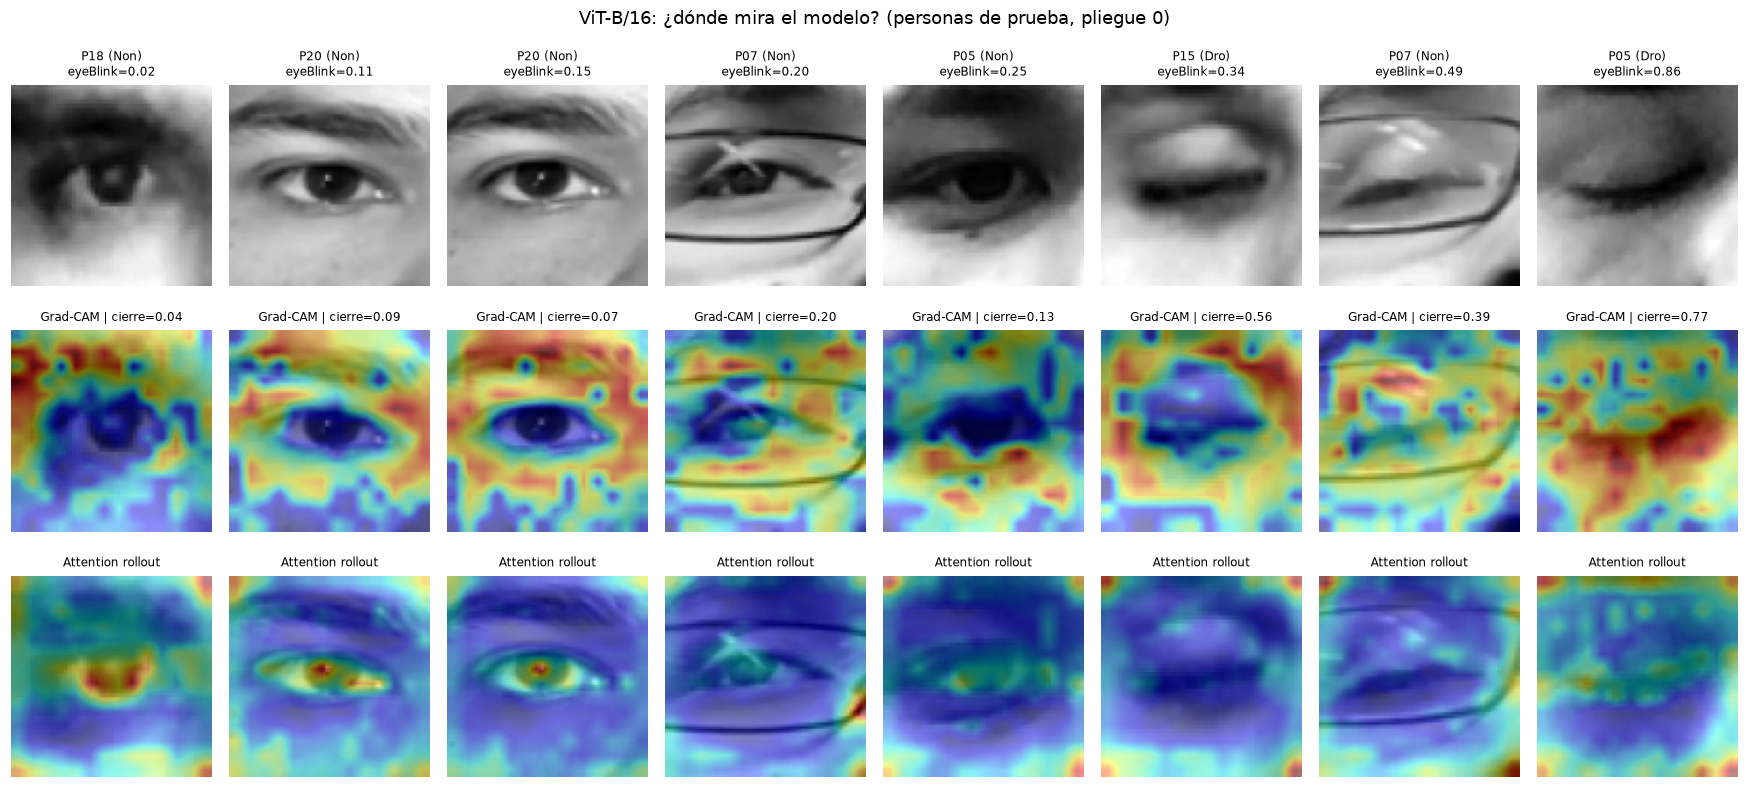

In [17]:
test0 = PRED[0].query("split == 'test'").sort_values("blink_L")
picks = test0.iloc[np.linspace(0, len(test0) - 1, 8).astype(int)]
n_rows = 2 if "VGG" in 'ViT-B/16' else 3
fig, axes = plt.subplots(n_rows, 8, figsize=(16, 2.3 * n_rows + 0.6))
upscale = lambda m, shape: np.array(Image.fromarray(np.uint8(m * 255)).resize(shape[::-1], Image.BILINEAR)) / 255
for col, (_, r) in enumerate(picks.iterrows()):
    i = int(D.index[D["rel_path"] == r["rel_path"]][0])
    x = make_batch(eyes_dev, torch.tensor([i], device=DEVICE), torch.tensor([0], device=DEVICE), False, 224, model.mean, model.std).float()
    cam, pred = grad_cam(model, x)
    eye = EYES[D.loc[i, "row"], 0]
    axes[0, col].imshow(eye, cmap="gray"); axes[0, col].set_title(f"{r['person']} ({CLASSES[r['label']][:3]})\neyeBlink={r['blink_L']:.2f}", fontsize=8)
    axes[1, col].imshow(eye, cmap="gray"); axes[1, col].imshow(upscale(cam, eye.shape), cmap="jet", alpha=0.45)
    axes[1, col].set_title(f"Grad-CAM | cierre={pred:.2f}", fontsize=8)
    if n_rows == 3:
        axes[2, col].imshow(eye, cmap="gray"); axes[2, col].imshow(upscale(attention_rollout(model, x.contiguous()), eye.shape), cmap="jet", alpha=0.45)
        axes[2, col].set_title("Attention rollout", fontsize=8)
for ax in axes.ravel(): ax.axis("off")
plt.suptitle(f"{'ViT-B/16'}: ¿dónde mira el modelo? (personas de prueba, pliegue 0)"); plt.tight_layout(); plt.show()

## 12. Complejidad y latencia

**Paper (Tabla 11):** el ViT tarda 1.021,83 ms por fotograma (0,98 FPS).
**Aquí:** tiempo por fotograma (los dos ojos) en este hardware, con precisión mixta.

In [18]:
def measure_latency(model, iters=30):
    x = torch.rand(2, 3, 224, 224, device=DEVICE).contiguous(memory_format=memory_format(DEVICE)); model.eval()
    sync = torch.cuda.synchronize if DEVICE.type == "cuda" else torch.mps.synchronize if DEVICE.type == "mps" else (lambda: None)
    with torch.no_grad(), torch.autocast(DEVICE.type, dtype=AMP_DTYPE):
        for _ in range(5): forward_logit(model, x)
        sync(); t0 = time.perf_counter()
        for _ in range(iters): forward_logit(model, x)
        sync()
    return (time.perf_counter() - t0) / iters * 1000

lat_model = build_model().to(DEVICE).to(memory_format=memory_format(DEVICE))   # misma arquitectura, atención rápida
lat = pd.DataFrame([{"Modelo": "ViT (paper, Tabla 11)", "Parámetros": "85,800,194", "ms/fotograma": 1021.83},
                    {"Modelo": f"ViT-B/16 ({HW})", "Parámetros": f"{sum(p.numel() for p in lat_model.parameters()):,}",
                     "ms/fotograma": round(measure_latency(lat_model), 1)}]).assign(FPS=lambda t: (1000 / t["ms/fotograma"]).round(1))
lat

,Modelo,Parámetros,ms/fotograma,FPS
0,"ViT (paper, Tabla 11)","85,800,194",1021.83,1.0
1,ViT-B/16 (Apple GPU (MPS)),"85,799,425",8.50,117.6


## 13. Resultados finales: ViT-B/16 y comparación con VGG19 + Attention

Resultados en **entrenamiento** y en **prueba** (personas no vistas), con validación cruzada de 5 pliegues por persona.
Los de VGG19 + Attention se leen de `results/ddd_full/`; los genera su propio notebook.

In [19]:
def corr_of(slug):
    folds = [pd.read_csv(RESULTS / slug / f"fold{k}.csv") for k in range(N_FOLDS)]
    return {s: np.mean([corr(p[p["split"] == s]) for p in folds]) for s in ("train", "test")}

rows = []
for name, slug, res_file in [("ViT-B/16", "vitb16", RESULTS / "resultados_vit.csv"),
                             ("VGG19 + Attention", "vgg19_attention", RESULTS / "resultados_cnn.csv")]:
    if not res_file.exists():
        print(f"Faltan los resultados de {name}: ejecuta su notebook."); continue
    r = pd.read_csv(res_file, index_col=[0, 1]).loc["calibrado por persona"]
    c = corr_of(slug)
    for conjunto, key in [("Entrenamiento", "train"), ("Prueba", "test")]:
        rows.append({"Modelo": name, "Conjunto": conjunto, "Correlación cierre": round(c[key], 3),
                     **{col: r.loc[conjunto, col] for col in r.columns}})
final = pd.DataFrame(rows).set_index(["Modelo", "Conjunto"])
final

Correlación cierre accuracy (%)  \
Modelo            Conjunto                                         
ViT-B/16          Entrenamiento               0.976   73.9 ± 2.4   
                  Prueba                      0.869   74.5 ± 4.6   
VGG19 + Attention Entrenamiento               0.980   74.4 ± 1.8   
                  Prueba                      0.912   71.6 ± 5.2   

                                precision (%) recall_drowsy (%)  \
Modelo            Conjunto                                        
ViT-B/16          Entrenamiento    84.0 ± 2.3        64.4 ± 3.1   
                  Prueba           81.3 ± 9.9        69.3 ± 9.8   
VGG19 + Attention Entrenamiento    83.2 ± 2.0        66.6 ± 2.1   
                  Prueba          78.4 ± 10.5        65.9 ± 6.3   

                                recall_alerta (%)      f1 (%)  
Modelo            Conjunto                                     
ViT-B/16          Entrenamiento        85.3 ± 1.9  72.9 ± 2.5  
                  Prueba              80.6 ± 14.4  74.0 ± 5.6  
VGG19 + Attention Entrenamiento        83.9 ± 2.0  73.9 ± 1.4  
                  Prueba              78.6 ± 12.9  71.1 ± 4.5

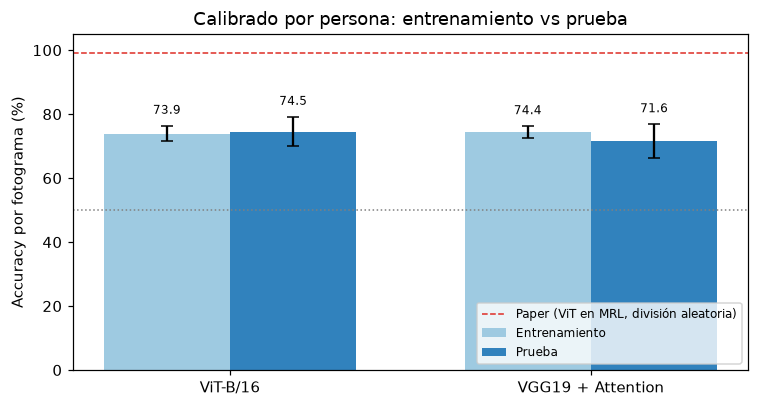

In [20]:
plot = final.reset_index()
plot["acc"] = plot["accuracy (%)"].str.split(" ± ").str[0].astype(float)
plot["err"] = plot["accuracy (%)"].str.split(" ± ").str[1].astype(float)
fig, ax = plt.subplots(figsize=(7, 3.8))
models = plot["Modelo"].unique(); w = 0.35
for j, (conjunto, color) in enumerate([("Entrenamiento", "#9ecae1"), ("Prueba", "#3182bd")]):
    sub = plot[plot["Conjunto"] == conjunto].set_index("Modelo").reindex(models)
    bars = ax.bar(np.arange(len(models)) + (j - 0.5) * w, sub["acc"], w, yerr=sub["err"], capsize=4, color=color, label=conjunto)
    ax.bar_label(bars, fmt="%.1f", padding=6, fontsize=8)
ax.axhline(50, color="gray", ls=":", lw=1); ax.axhline(99.15, color="#de2d26", ls="--", lw=1, label="Paper (ViT en MRL, división aleatoria)")
ax.set(xticks=np.arange(len(models)), xticklabels=models, ylabel="Accuracy por fotograma (%)", ylim=(0, 105),
       title="Calibrado por persona: entrenamiento vs prueba")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

### Conclusiones

1. **Paper vs. aquí:** el paper obtiene ~99 % porque su división aleatoria pone fotos casi idénticas de la misma persona en entrenamiento y en prueba. Aquí se evalúa con **personas que el modelo nunca vio**, así que las cifras son menores pero reales.
2. **Entrenamiento vs. prueba:** la diferencia entre ambos muestra cuánto pierde el modelo al pasar a personas nuevas. Una diferencia pequeña indica que no memorizó a las personas.
3. **Lo que se toma del paper:** el mismo modelo (ViT-B/16) con sus pesos preentrenados, los hiperparámetros base, el recorte de la región de los ojos, la clasificación del estado del ojo y la interpretabilidad.
4. **Lo que se ajusta:** división por persona, etiqueta del ojo por imagen, calibración por persona y prueba de fuga.
5. **Límite del dataset:** la etiqueta *Drowsy* es de todo el video, y muchas fotos "somnolientas" tienen los ojos abiertos. En una sola foto, eso no se puede ver.

## Tabla final de resultados

Evaluación **por fotograma**, calibrada por persona, con validación cruzada de **5 pliegues por persona** sobre el DDD completo (41.793 imágenes). En la prueba se usan solo **personas que el modelo nunca vio**.

| Modelo | Conjunto | Correlación cierre | Accuracy | Detecta Drowsy | Reconoce alerta | F1 |
|---|---|---|---|---|---|---|
| **VGG19 + Attention** | Entrenamiento | 0,980 | 74,4 ± 1,8 % | 66,6 % | 83,9 % | 73,9 % |
| | **Prueba** | **0,912** | 71,6 ± 5,2 % | 65,9 % | 78,6 % | 71,1 % |
| **ViT-B/16** | Entrenamiento | 0,976 | 73,9 ± 2,4 % | 64,4 % | 85,3 % | 72,9 % |
| | **Prueba** | 0,869 | **74,5 ± 4,6 %** | **69,3 %** | **80,6 %** | **74,0 %** |

**Lectura de la tabla:**
- **Los dos generalizan a personas nuevas.** La accuracy en prueba queda muy cerca de la de entrenamiento: en la CNN baja menos de 3 puntos y en el ViT incluso sube un poco. Ninguno memorizó a las personas.
- **Cada modelo gana en algo.** VGG19 + Attention estima mejor el **cierre del ojo** (correlación 0,91 contra 0,87 en prueba), pero el ViT **clasifica mejor la somnolencia** en todas las métricas de prueba.
- **Los dos pasan la prueba de fuga**, con 91 % y 88 % de las fotos alertas bien reconocidas con una referencia somnolienta: miden el ojo, no el cambio de video.
- **Tiempo real:** unos 7 ms (CNN) y 9 ms (ViT) por fotograma en un Mac, frente a los 1.022 ms del ViT del paper.
- **Frente al paper:** su ~99 % viene de una división aleatoria con fotos casi idénticas en entrenamiento y prueba. Aquí, con personas nuevas, el resultado real es de **72–75 %**.